# Obesidade e Estilo de Vida

## Contexto
Este estudo utiliza uma base de dados contendo informações demográficas,
hábitos alimentares e estilo de vida, com o objetivo de entender fatores
associados aos diferentes níveis de obesidade.

## Pergunta central
Quais hábitos e comportamentos estão mais associados aos níveis mais elevados
de obesidade?

## Objetivo
Explorar padrões, relações e possíveis fatores de risco ou proteção
relacionados à obesidade.

# Importações

## Bibliotecas

In [1]:
# Importando as bibliotecas
import pandas as pd
import apoio

# classe com funções auxiliares
ap = apoio.Apoio()

A classe Graficos esta sendo utilizada para haver um melhor aproveitamento do espaço e focar mais nas análises e menos no código-fonte.

## Visão inicial dos dados da pesquisa

In [2]:

df_pesquisa  = pd.read_csv("Obesity.csv", sep=",")
display(df_pesquisa.head())
print("Total de registros", df_pesquisa.shape[0])

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


Total de registros 2111


Observa-se que a base contém variáveis categóricas relacionadas a hábitos
alimentares, comportamento e estilo de vida, além da variável alvo que indica
o nível de obesidade.


# Preparação

## Do Dicionário de Dados

In [3]:
dados = [

    # PERFIL DAS PESSOAS
    #===================

    # Gender
    ("gender", "Sexo biológico", "Female", "Feminino"),
    ("gender", "Sexo biológico", "Male", "Masculino"),

    # family_history
    ("family_history", "Histórico familiar de excesso de peso", "yes", "Há histórico"),
    ("family_history", "Histórico familiar de excesso de peso", "no", "Não há histórico"),

    # CARACTERÍSTICAS ALIMENTARES
    #============================

    # FAVC
    ("favc", "Consumo frequente de alimentos altamente calóricos", "yes", "Sim"),
    ("favc", "Consumo frequente de alimentos altamente calóricos", "no", "Não"),

    # FCVC
    ("fcvc", "Frequência de consumo de vegetais nas refeições", 1, "Raramente"),
    ("fcvc", "Frequência de consumo de vegetais nas refeições", 2, "Às vezes"),
    ("fcvc", "Frequência de consumo de vegetais nas refeições", 3, "Sempre"),

    # NCP
    ("ncp", "Número de refeições principais por dia", 1, "Uma refeição"),
    ("ncp", "Número de refeições principais por dia", 2, "Duas refeições"),
    ("ncp", "Número de refeições principais por dia", 3, "Três refeições"),
    ("ncp", "Número de refeições principais por dia", 4, "Quatro ou mais refeições"),

    # CAEC
    ("caec", "Consumo de alimentos entre as refeições", "no", "Não consome"),
    ("caec", "Consumo de alimentos entre as refeições", "Sometimes", "Às vezes"),
    ("caec", "Consumo de alimentos entre as refeições", "Frequently", "Frequentemente"),
    ("caec", "Consumo de alimentos entre as refeições", "Always", "Sempre"),
    
    # ESTILO DE VIDA
    #===============

    # FAF
    ("faf", "Frequência semanal de atividade física", 0, "Nenhuma"),
    ("faf", "Frequência semanal de atividade física", 1, "1–2 vezes"),
    ("faf", "Frequência semanal de atividade física", 2, "3–4 vezes"),
    ("faf", "Frequência semanal de atividade física", 3, "5 vezes ou mais"),

    # TUE
    ("tue", "Tempo diário usando dispositivos eletrônicos", 0, "0–2 horas/dia"),
    ("tue", "Tempo diário usando dispositivos eletrônicos", 1, "3–5 horas/dia"),
    ("tue", "Tempo diário usando dispositivos eletrônicos", 2, "Mais de 5 horas/dia"),

    # MTRANS
    ("mtrans", "Meio de transporte habitual", "Automobile", "Carro"),
    ("mtrans", "Meio de transporte habitual", "Motorbike", "Moto"),
    ("mtrans", "Meio de transporte habitual", "Bike", "Bicicleta"),
    ("mtrans", "Meio de transporte habitual", "Public_Transportation", "Transporte público"),
    ("mtrans", "Meio de transporte habitual", "Walking", "A pé"),

    # COMPORTAMENTOS ADICIONAIS
    #==========================

    # CH2O
    ("ch2o", "Consumo diário de água", 1, "Menos de 1 litro/dia"),
    ("ch2o", "Consumo diário de água", 2, "Entre 1 e 2 litros/dia"),
    ("ch2o", "Consumo diário de água", 3, "Mais de 2 litros/dia"),
    
    # CALC
    ("calc", "Consumo de bebida alcoólica", "no", "Não bebe"),
    ("calc", "Consumo de bebida alcoólica", "Sometimes", "Às vezes"),
    ("calc", "Consumo de bebida alcoólica", "Frequently", "Frequentemente"),
    ("calc", "Consumo de bebida alcoólica", "Always", "Sempre"),
    
    # SMOKE
    ("smoke", "Hábito de fumar", "yes", "Fuma"),
    ("smoke", "Hábito de fumar", "no", "Não fuma"),

    # SCC
    ("scc", "Monitora a ingestão calórica diária", "yes", "Sim"),
    ("scc", "Monitora a ingestão calórica diária", "no", "Não"),

    # TARGET
    #=======
    
    # Obesity
    ("obesity", "Nível de obesidade (coluna alvo)", "Insufficient_Weight", "Abaixo do peso"),
    ("obesity", "Nível de obesidade (coluna alvo)", "Normal_Weight", "Peso normal"),
    ("obesity", "Nível de obesidade (coluna alvo)", "Overweight_Level_I", "Sobrepeso nível I"),
    ("obesity", "Nível de obesidade (coluna alvo)", "Overweight_Level_II", "Sobrepeso nível II"),
    ("obesity", "Nível de obesidade (coluna alvo)", "Obesity_Type_I", "Obesidade tipo I"),
    ("obesity", "Nível de obesidade (coluna alvo)", "Obesity_Type_II", "Obesidade tipo II"),
    ("obesity", "Nível de obesidade (coluna alvo)", "Obesity_Type_III", "Obesidade tipo III"),
]

df_dicionario = pd.DataFrame(
    dados,
    columns=["cd_variavel", "ds_variavel", "nr_categoria", "ds_categoria"]
)

# cria a coluna sk_categoria reiniciando em 1 para cada cd_variavel
df_dicionario["sk_categoria"] = (
    df_dicionario
    .groupby("cd_variavel")
    .cumcount()
    + 1
)

# dicionário gerado em CSV para apoio ao App desenvolvido no Streamlit
df_dicionario.to_csv('dicionario.csv', sep=';', index=False)

df_dicionario.head()

,cd_variavel,ds_variavel,nr_categoria,ds_categoria,sk_categoria
0,gender,Sexo biológico,Female,Feminino,1
1,gender,Sexo biológico,Male,Masculino,2
2,family_history,Histórico familiar de excesso de peso,yes,Há histórico,1
3,family_history,Histórico familiar de excesso de peso,no,Não há histórico,2
4,favc,Consumo frequente de alimentos altamente calór...,yes,Sim,1


O dicionário de dados foi transcrito a partir do PDF original e 
recebeu essa estrutura para facilitar a compreensão dos dados.

Nesse formato é possível interpretar corretamente as categorias,
traduzindo códigos técnicos em descrições compreensíveis, o que facilita
a análise e a comunicação dos resultados.

## Da Pesquisa

In [4]:
# transformando o nome das colunas em minúsculo
df_pesquisa.columns = df_pesquisa.columns.str.lower()

df_pesquisa.head()

,gender,age,height,weight,family_history,favc,fcvc,ncp,caec,smoke,ch2o,scc,faf,tue,calc,mtrans,obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


É transformado todos os títulos das colunas em minúsculas a fim de, obter uma padronização e facilitar a exploração das análises.

In [5]:
print("Total de valores nulos encontrados: ", df_pesquisa.isnull().sum().sum(), "\n")

print("Valore únicos encontrados")
print(df_pesquisa.nunique())

Total de valores nulos encontrados:  0 

Valore únicos encontrados
gender               2
age               1402
height            1574
weight            1525
family_history       2
favc                 2
fcvc               810
ncp                635
caec                 4
smoke                2
ch2o              1268
scc                  2
faf               1190
tue               1129
calc                 4
mtrans               5
obesity              7
dtype: int64


In [6]:
# conversões e arredondamentos
df_pesquisa['age'] = df_pesquisa['age'].astype(int)

for c in ['fcvc', 'ncp', 'ch2o', 'faf', 'tue']:
    df_pesquisa[c] = ap.arredonda_inteiro_mais_proximo(df_pesquisa[c]).astype(int)

df_pesquisa['height'] = df_pesquisa['height'].round(2) # metros
df_pesquisa['weight'] = df_pesquisa['weight'].round(3) # kilogramas

É realizada a conversão do tipo da váriável idade para o tipo inteiro, já outras variáveis tiveram seu arredondamento padronizado seguindo as orientações contidas no dicionário de dados.
A altura foi arredondada para dois dígitos decimais.
O peso foi arredondado para três dígitos decimais.

## Adição do IMC a pesquisa

In [7]:
def classificar_imc(imc):
    if imc < 18.5:
        return "Abaixo do peso"
    elif imc < 25:
        return "Peso normal"
    elif imc < 30:
        return "Sobrepeso"
    elif imc < 35:
        return "Obesidade tipo I"
    elif imc < 40:
        return "Obesidade tipo II"
    else:
        return "Obesidade tipo III"
    
# Cria e adiciona a coluna de IMC
df_pesquisa["imc"] = df_pesquisa["weight"] / (df_pesquisa["height"] ** 2)
df_pesquisa["ds_imc_oms"] = df_pesquisa.imc.apply(classificar_imc)

df_pesquisa = df_pesquisa.merge(
    df_dicionario[df_dicionario['cd_variavel'] == 'obesity'][['nr_categoria', 'ds_categoria']],
    left_on='obesity',
    right_on='nr_categoria',
    how='left'
)

df_pesquisa.rename(columns={'ds_categoria':'ds_imc_dicionario'}, inplace=True)
df_pesquisa.drop(columns='nr_categoria', inplace=True)

df_pesquisa.loc[df_pesquisa.ds_imc_dicionario != df_pesquisa.ds_imc_oms].groupby(['ds_imc_dicionario','ds_imc_oms']).size().reset_index(name="qtd_registros")

,ds_imc_dicionario,ds_imc_oms,qtd_registros
0,Abaixo do peso,Peso normal,5
1,Obesidade tipo I,Obesidade tipo II,2
2,Obesidade tipo I,Sobrepeso,3
3,Obesidade tipo II,Obesidade tipo I,20
4,Obesidade tipo III,Obesidade tipo II,61
5,Peso normal,Abaixo do peso,3
6,Sobrepeso nível I,Peso normal,13
7,Sobrepeso nível I,Sobrepeso,277
8,Sobrepeso nível II,Obesidade tipo I,3
9,Sobrepeso nível II,Sobrepeso,287


A inclusão do IMC conforme o padrão da Organização Mundial da Saúde tem como objetivo exclusivo possibilitar a comparação entre as descrições dos graus de obesidade adotadas neste estudo e a classificação internacionalmente reconhecida.

Observou-se que a nomenclatura utilizada no dicionário segue parcialmente o padrão estabelecido pela OMS; entretanto, em determinados casos, há divergências na descrição das categorias quando se considera o mesmo índice de massa corporal em ambas as fontes. Outro detalhe é que a OMS não cria tipos para Sobrepeso, como consta no dicionário, Tipo I e II.

A fim de preservar a coerência metodológica e não alterar o escopo original da pesquisa, optou-se por manter o dicionário inicialmente definido como base de categorização. Ainda assim, registra-se essa diferença como uma observação relevante para fins de transparência e rigor técnico.

## Validação: Pesquisa x Dicionário

In [8]:
# cria um dicionário de dicionários
mapas = (
    df_dicionario
    .groupby("cd_variavel")[["nr_categoria", "sk_categoria"]]
    .apply(lambda x: dict(zip(x["nr_categoria"], x["sk_categoria"])))
    .to_dict()
)

# cruzamento do dicionário com a pesquisa
df_codificado = df_pesquisa.copy()

for col in df_codificado.columns:
    if col in mapas:
        df_codificado[col] = df_codificado[col].map(mapas[col])

# verifica se há valores no dataset que não existem no dicionário.
colunas_com_problema = [
    col for col in mapas
    if col in df_codificado.columns and df_codificado[col].isna().any()
]

if len(colunas_com_problema) > 0:
    print("Há valores inexistentes no dicionário de dados nas colunas:", colunas_com_problema)

# pesquisa codificada gerada em CSV para apoio ao App desenvolvido no Streamlit
df_codificado.to_csv('pesquisa_codificada.csv', sep=';', index=False)

df_codificado.head()

,gender,age,height,weight,family_history,favc,fcvc,ncp,caec,smoke,ch2o,scc,faf,tue,calc,mtrans,obesity,imc,ds_imc_oms,ds_imc_dicionario
0,1,21,1.62,64.0,1,2,2,3,2,2,2,2,1,2,1,4,2,24.386526,Peso normal,Peso normal
1,1,21,1.52,56.0,1,2,3,3,2,1,3,1,4,1,2,4,2,24.238227,Peso normal,Peso normal
2,2,23,1.80,77.0,1,2,2,3,2,2,2,2,3,2,3,4,2,23.765432,Peso normal,Peso normal
3,2,27,1.80,87.0,2,2,3,3,2,2,2,2,3,1,3,5,3,26.851852,Sobrepeso,Sobrepeso nível I
4,2,22,1.78,89.8,2,2,2,1,2,2,2,2,1,1,2,4,4,28.342381,Sobrepeso,Sobrepeso nível II


Como demonstrado, todos os valores contidos no dataset estão padronizados e pertencem a uma categoria do dicionário, exceto as colunas de idade, peso e altura, pois são valores que não serão categorizados. No futuro o df_codificado será utilizado para a construção do Modelo de Machine Learning Preditivo.      

## Transformações e Cruzamentos

In [9]:
ap.gerar_df_longo(df_pesquisa, df_dicionario)
ap.df_longo.head()

,age,height,weight,obesity,cd_variavel,nr_categoria,ds_obesidade,ds_variavel,ds_categoria,sk_categoria
0,21,1.62,64.0,Normal_Weight,gender,Female,Peso normal,Sexo biológico,Feminino,1.0
1,21,1.52,56.0,Normal_Weight,gender,Female,Peso normal,Sexo biológico,Feminino,1.0
2,23,1.80,77.0,Normal_Weight,gender,Male,Peso normal,Sexo biológico,Masculino,2.0
3,27,1.80,87.0,Overweight_Level_I,gender,Male,Sobrepeso nível I,Sexo biológico,Masculino,2.0
4,22,1.78,89.8,Overweight_Level_II,gender,Male,Sobrepeso nível II,Sexo biológico,Masculino,2.0


A transformação do df_pesquisa em df_longo é o mais indicado para a realização do storytelling

# Análises Exploratórias

## O perfil das pessoas

### Como se distribuem os tipos de obesidade por sexo?

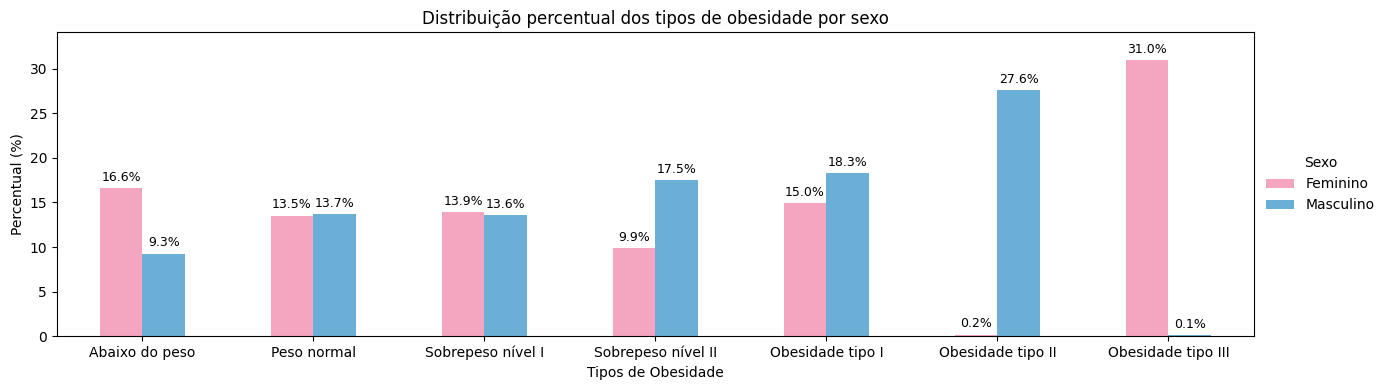

In [10]:
ap.grafico_tipos_obesidade_por_sexo()

A análise por sexo revela padrões distintos de distribuição dos tipos de obesidade.
No grupo feminino (1043 mulheres), observa-se uma polarização maior, com presença significativa tanto de indivíduos abaixo do peso quanto de obesidade severa (tipo III).

No grupo masculino (1068 homens), a concentração se desloca para os níveis intermediários e altos de obesidade, com maior representatividade em sobrepeso nível II, obesidade tipo I e, principalmente, obesidade tipo II, sugerindo um acúmulo progressivo de peso em faixas menos extremas quando comparado ao grupo feminino.


### Como se distribuem os tipos de obesidades por faixa etária?

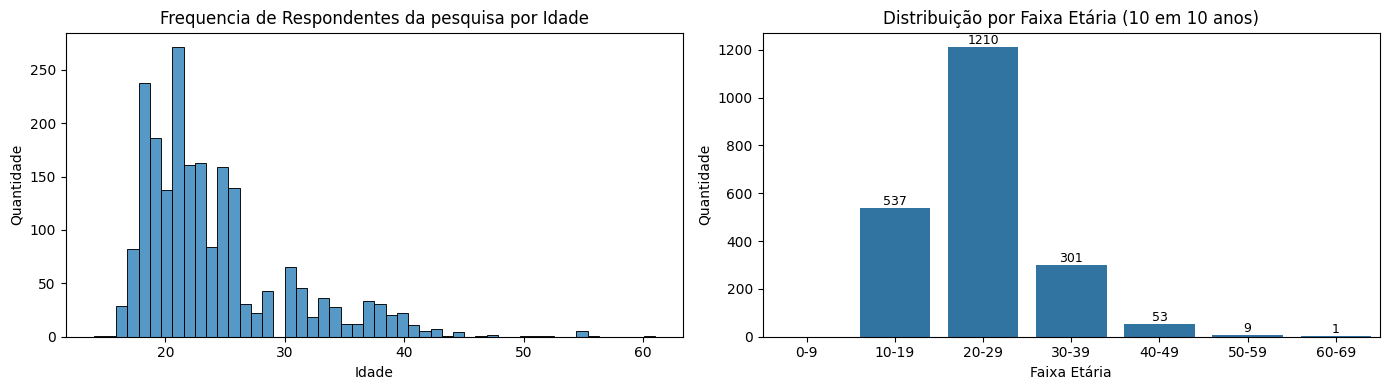

In [11]:
ap.grafico_frequencia_idade_e_faixa_etaria()

Antes de analisar a distribuição dos tipos de obesidade por faixa etária é importante demonstrar como  está a frequência da idade e o agrupamento por faixa etária das pessoas pesquisadas. Os gráficos evidenciam uma população mais jovem, abaixo dos 50 anos, com predominância a faixa dos 20 aos 29 anos de idade.

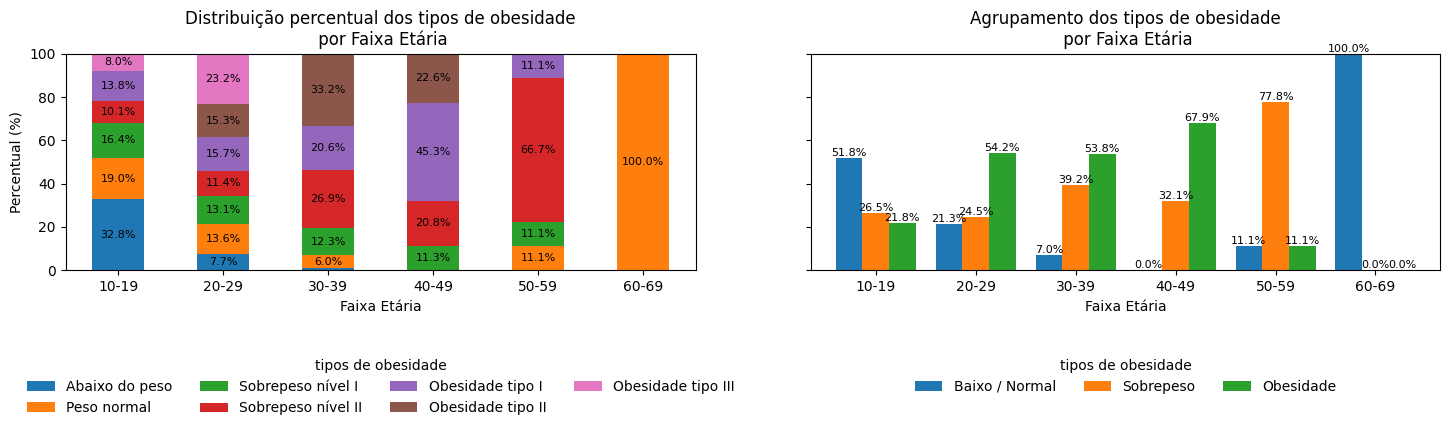

In [12]:
ap.grafico_tipos_obesidade_por_faixa_etaria()

A distribuição dos tipos de obesidade por faixa etária mostra uma mudança progressiva no perfil nutricional ao longo da idade. Na faixa de 10 a 19 anos, observa-se alta variabilidade, com presença relevante tanto de indivíduos abaixo do peso quanto com obesidade. A partir dos 20 anos, ocorre redução significativa do baixo peso e aumento consistente dos níveis de sobrepeso e obesidade. Entre 30 e 49 anos, o excesso de peso torna-se predominante, com forte concentração nos tipos mais elevados de obesidade. Nessa fase, o percentual de indivíduos com peso normal é bastante reduzido. Nas faixas acima de 50 anos, os percentuais apresentam comportamentos atípicos, sugerindo possível tamanho amostral reduzido, o que exige cautela na interpretação. De forma geral, os dados indicam aumento progressivo da obesidade até a meia-idade, com ponto crítico de transição entre 20 e 39 anos.

### Como o histórico familiar influência a distribuição dos níveis de obesidade?

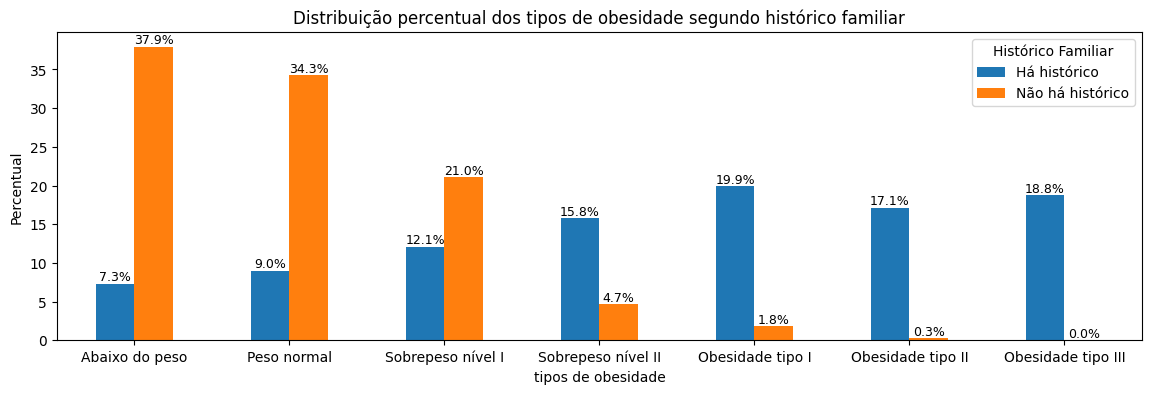

In [13]:
ap.grafico_historico_familiar()

Ao analisar o histórico familiar, observa-se uma mudança clara no perfil de obesidade. Indivíduos com histórico apresentam maior concentração nos níveis mais elevados, enquanto aqueles sem histórico estão majoritariamente distribuídos entre peso normal e abaixo do peso


### Conclusão sobre o perfil das pessoas

Ao analisar o perfil das pessoas, fica evidente que a obesidade não se distribui de maneira homogênea — ela segue padrões claros relacionados a sexo, idade e histórico familiar.

Homens e mulheres apresentam comportamentos distintos na progressão do peso: enquanto o grupo feminino demonstra maior polarização entre extremos, o grupo masculino concentra-se nos níveis intermediários e elevados, sugerindo um processo gradual de acúmulo de peso.

A idade revela um ponto crítico importante: a transição entre os 20 e 39 anos marca o início de um crescimento consistente do excesso de peso, consolidando-se na meia-idade como padrão predominante.

Além disso, o histórico familiar surge como um fator fortemente associado aos níveis mais elevados de obesidade, reforçando a influência de componentes genéticos e ambientais compartilhados.

Em conjunto, esses achados mostram que o perfil individual importa — mas não explica tudo.
Se sexo, idade e herança familiar desenham o cenário, resta uma pergunta fundamental:

Até que ponto os hábitos cotidianos reforçam ou modificam esse risco?

E é exatamente isso que exploraremos no próximo capítulo.

## A características alimentares

### Os níveis de obesidade mais severos podem estar associados ao consumo frequente de alimentos altamente calóricos?

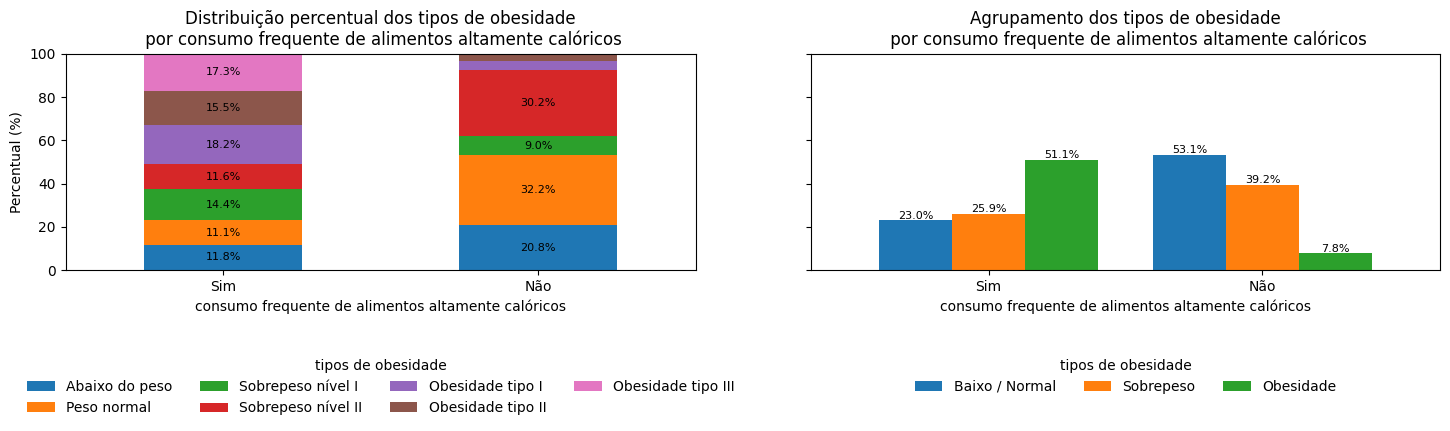

In [14]:
ap.grafigo_alimentos_altamente_caloricos()

Observa-se uma associação clara entre o consumo frequente de alimentos altamente calóricos e a presença de níveis mais severos de obesidade. Enquanto indivíduos que não relatam consumo frequente concentram-se majoritariamente em peso normal e sobrepeso, aqueles que consomem com frequência apresentam distribuição progressivamente deslocada para obesidade tipo I, II e III, indicando maior severidade do quadro.

### Como o perfil de obesidade varia conforme a frequência de consumo de vegetais?

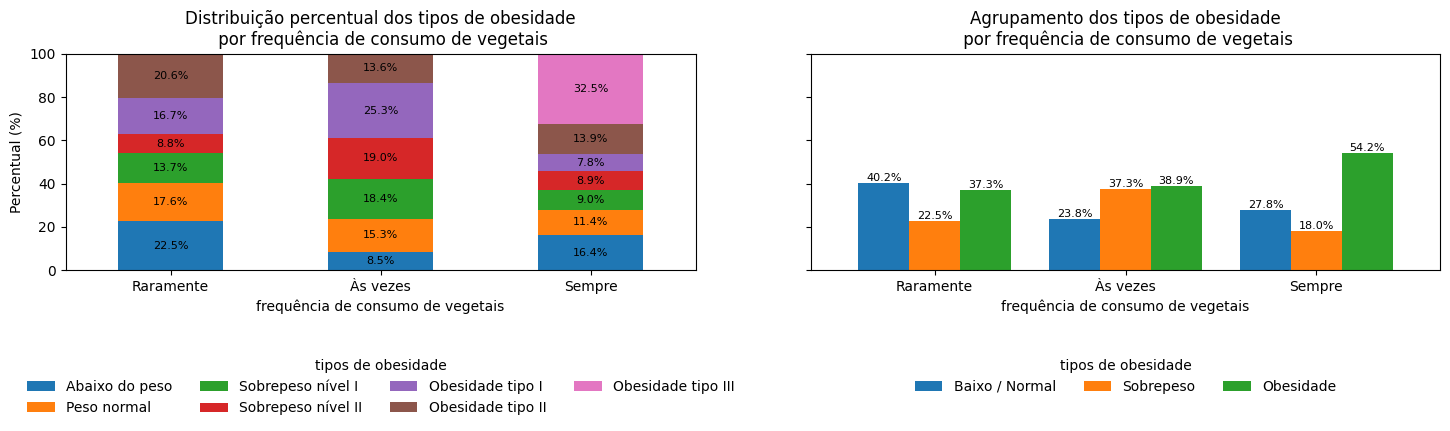

In [15]:
ap.grafico_consumo_de_vegetais()

Ao analisar a distribuição percentual dos graus de obesidade segundo a frequência de consumo de vegetais, observa-se que os perfis variam significativamente entre os grupos.
Indivíduos que relatam consumir vegetais ‘às vezes’ apresentam maior concentração nos graus de sobrepeso e obesidade tipo I.
Já no grupo que consome vegetais ‘sempre’, nota-se uma presença relevante de obesidade tipo III, sugerindo que o consumo frequente, isoladamente, não é suficiente para explicar um perfil de peso mais saudável.
Categorias com 0% indicam ausência de registros na amostra.

### O número de refeições principais por dia está associado a diferenças no perfil de obesidade?

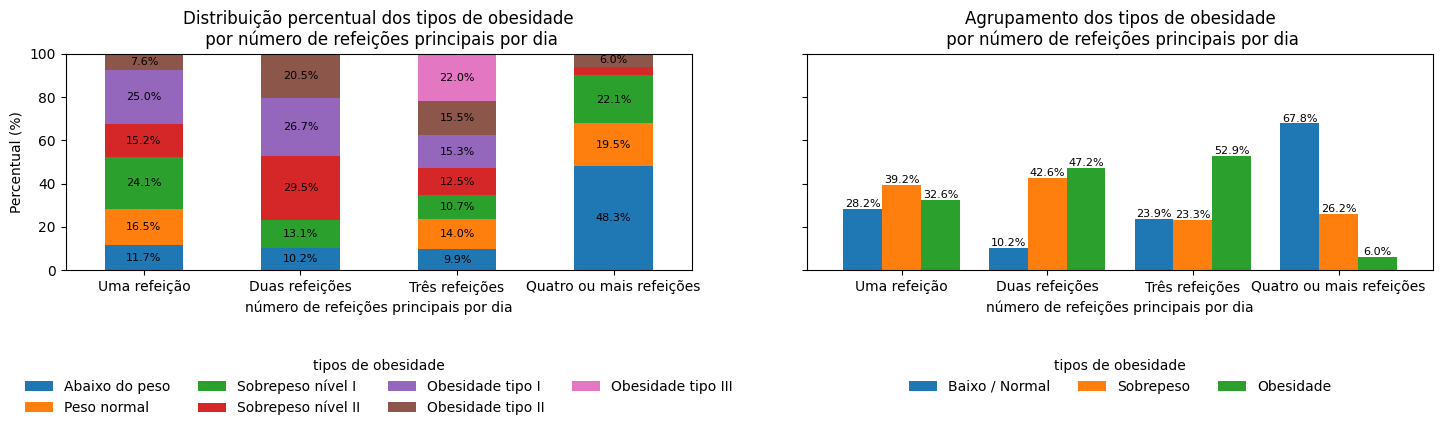

In [16]:
ap.grafico_refeicoes_principais()


A distribuição percentual dos níveis de obesidade varia de forma significativa conforme o número de refeições principais realizadas por dia.
Indivíduos que realizam apenas uma ou duas refeições concentram-se majoritariamente nos níveis de sobrepeso e obesidade, com destaque para sobrepeso nível II e obesidade tipo I.
No grupo que realiza três refeições diárias, observa-se uma distribuição mais equilibrada entre os níveis, porém com presença relevante de obesidade tipo III, indicando maior severidade nesse perfil.
Já entre aqueles que realizam quatro ou mais refeições, destaca-se a elevada participação de indivíduos abaixo do peso e peso normal, acompanhada de menor concentração nos níveis mais severos de obesidade.
Esses resultados sugerem uma associação entre o padrão de refeições diárias e o perfil de obesidade, reforçando a complexidade dos comportamentos alimentares e a impossibilidade de inferir causalidade direta.
Categorias com 0% indicam ausência de registros na amostra analisada.

### Consumir alimentos entre as refeições está associado a diferenças no perfil de peso?

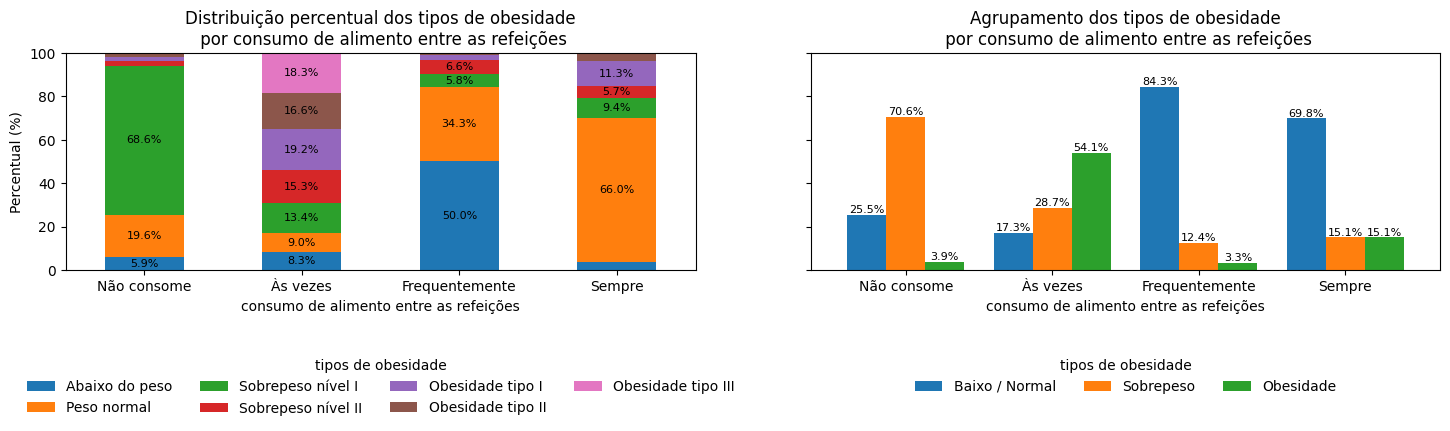

In [17]:
ap.grafico_alimento_entre_refeicoes()

O gráfico evidencia que a frequência de consumo de alimentos entre as refeições está associada a diferentes perfis de obesidade. Indivíduos que consomem frequentemente ou sempre tendem a se concentrar nos grupos de peso normal e abaixo do peso, enquanto aqueles que não consomem apresentam maior predominância de sobrepeso nível I. Já o consumo ocasional mostra uma distribuição mais dispersa entre os níveis de obesidade, sugerindo um padrão alimentar menos regular e potencialmente menos favorável ao controle do peso.

### Conclusão da características alimentares

A análise das características alimentares revela que a relação entre alimentação e obesidade é multifatorial e mais complexa do que aparenta.

O consumo frequente de alimentos altamente calóricos demonstra associação clara com os níveis mais severos de obesidade, indicando um possível efeito acumulativo na progressão do excesso de peso. Nesse caso, o padrão alimentar atua como um intensificador do risco já identificado no perfil demográfico.

Por outro lado, variáveis tradicionalmente associadas a um padrão saudável, como o consumo frequente de vegetais, mostram que isoladamente não são suficientes para garantir um perfil de peso mais favorável. Isso sugere que qualidade alimentar não pode ser analisada de forma fragmentada.

O número de refeições diárias também evidencia diferenças importantes: padrões com maior regularidade (quatro ou mais refeições) apresentam menor concentração nos níveis mais severos, enquanto padrões mais restritivos concentram-se em sobrepeso e obesidade.

Curiosamente, o consumo entre refeições não se comporta como um vilão absoluto — quando frequente, aparece associado a maior presença de peso normal, enquanto o padrão ocasional demonstra maior dispersão nos níveis de obesidade.

Em conjunto, os dados indicam que não existe um único hábito determinante, mas sim uma combinação de comportamentos que interagem entre si. A obesidade, portanto, não parece ser resultado de um fator isolado, mas de um padrão alimentar estruturado ao longo do tempo.

Diante disso, surge uma nova questão fundamental:

Se a alimentação explica parte do fenômeno, até que ponto o estilo de vida — como atividade física, rotina e comportamento sedentário — potencializa ou atenua esses efeitos?

## Estilo de Vida

### A prática regular de atividade física contribui para um melhor controle do peso corporal?

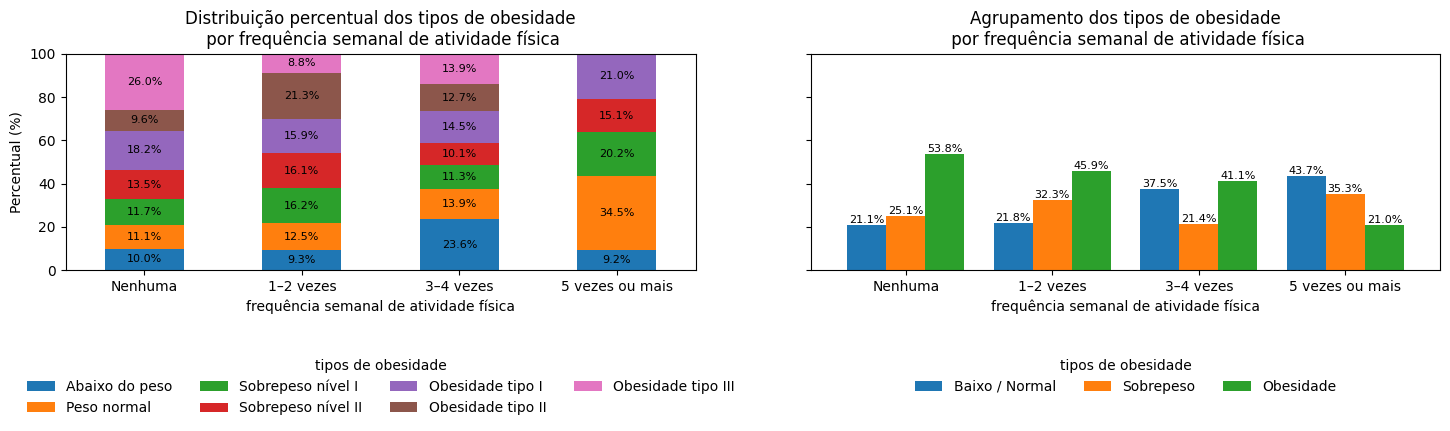

In [18]:
ap.grafico_pratica_atividade_fisica()

Os dados sugerem que maiores frequências de atividade física estão associadas a perfis de peso mais equilibrados, com maior concentração de indivíduos em peso normal entre aqueles que se exercitam regularmente. Em contraste, a ausência de atividade física está relacionada a uma distribuição mais ampla entre os níveis de sobrepeso e obesidade, incluindo graus mais severos. Esses padrões indicam que a prática regular de atividade física pode contribuir para um melhor controle do peso corporal.

### O tempo diário de uso de dispositivos eletrônicos influencia o controle do peso corporal?

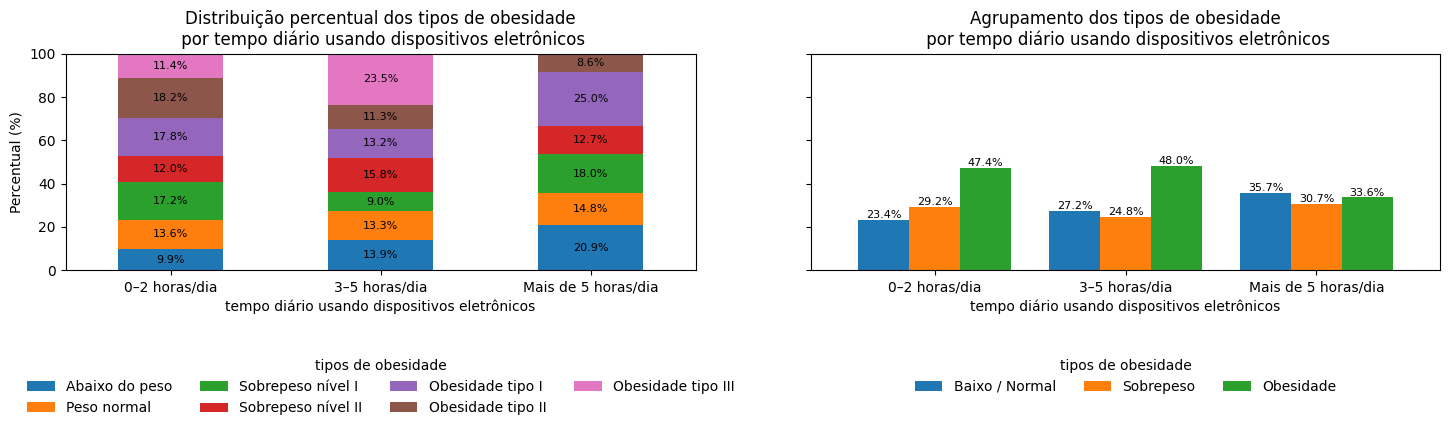

In [19]:
ap.grafico_tempo_uso_eletronico()

Os dados indicam que o tempo de uso de dispositivos eletrônicos pode estar associado ao perfil de obesidade, embora a relação não seja totalmente linear.
Indivíduos que utilizam dispositivos por **3–5 horas/dia** apresentam maior concentração em obesidade tipo III, sugerindo maior severidade nesse grupo. Já aqueles com **mais de 5 horas/dia** concentram-se principalmente em obesidade tipo I, mas também apresentam distribuição dispersa entre outras categorias.
O grupo com **0–2 horas/dia** demonstra perfil mais equilibrado entre os níveis de peso.
De forma geral, os resultados sugerem que maior tempo de exposição a dispositivos — possivelmente associado a comportamento sedentário — pode influenciar o controle do peso, exigindo, porém, interpretação cautelosa.

### Existem diferenças no perfil de obesidade entre os meios de transporte habituais?

<p style="color:red;">A análise do meio de transporte habitual deve ser interpretada com cautela, devido à baixa representatividade de meios como: A pé, Bicicleta e Moto, que somados não chega a ~3% da amostra.</p>


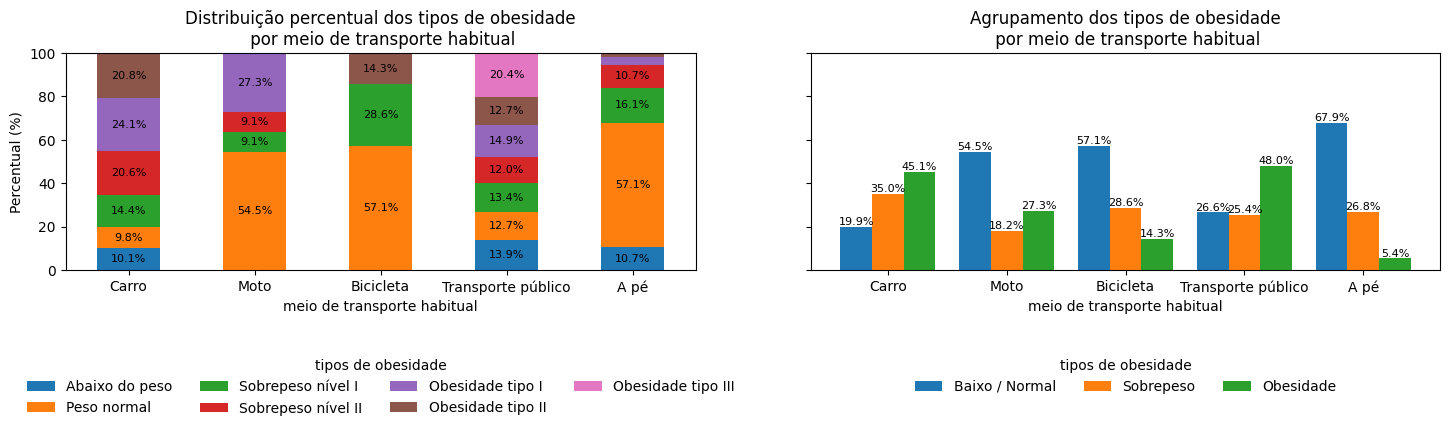

In [20]:
ap.grafico_meio_transporte_habitual()

O gráfico sugere diferenças na distribuição dos níveis de obesidade entre os meios de transporte habituais. Observa-se que formas de deslocamento mais ativas, como caminhar e utilizar bicicleta, apresentam maior concentração de indivíduos em peso normal; entretanto, esses resultados devem ser interpretados com cautela devido à baixa representatividade dessas categorias na amostra. Em contraste, o uso de carro e transporte público, que concentram a maior parte dos indivíduos, apresenta uma distribuição mais equilibrada e consistente entre os diferentes níveis de obesidade. Assim, embora haja indícios de associação entre o tipo de transporte e o perfil de peso corporal, os dados não permitem afirmar que o uso de meios de transporte mais ativos contribui diretamente para um melhor controle do peso, sendo necessária a consideração de outras variáveis comportamentais.

### Conclusão do estilo de vida

A análise do estilo de vida reforça que o controle do peso corporal está fortemente associado a padrões comportamentais cotidianos.

A prática regular de atividade física apresenta relação consistente com perfis de peso mais equilibrados, sugerindo efeito protetor contra níveis mais severos de obesidade. Em contraste, a ausência de exercício físico amplia a dispersão entre sobrepeso e obesidade, incluindo graus mais elevados.

O tempo de uso de dispositivos eletrônicos indica possível influência do comportamento sedentário no perfil de peso, embora os dados revelem padrões não lineares, sugerindo que o sedentarismo pode interagir com outros fatores alimentares e individuais.

Quanto aos meios de transporte, observa-se que formas mais ativas apresentam maior concentração em peso normal, mas a baixa representatividade dessas categorias limita conclusões definitivas. Já os meios predominantemente passivos demonstram distribuição mais consistente entre níveis de sobrepeso e obesidade.

Em conjunto, os resultados indicam que o estilo de vida atua como modulador do risco: enquanto a alimentação pode intensificar a progressão da obesidade, os comportamentos diários — especialmente atividade física e nível de sedentarismo — parecem influenciar a direção e a intensidade desse processo.

Se nos capítulos anteriores identificamos o perfil demográfico e os padrões alimentares, agora compreendemos que o movimento (ou a ausência dele) pode potencializar ou mitigar esses efeitos.

A próxima etapa da análise amplia ainda mais essa compreensão:

Como comportamentos adicionais — como ingestão de água, consumo de álcool, tabagismo e monitoramento calórico — se integram a esse cenário?

## Comportamentos Adicionais

### A ingestão adequada de água contribui para um melhor controle do peso corporal?

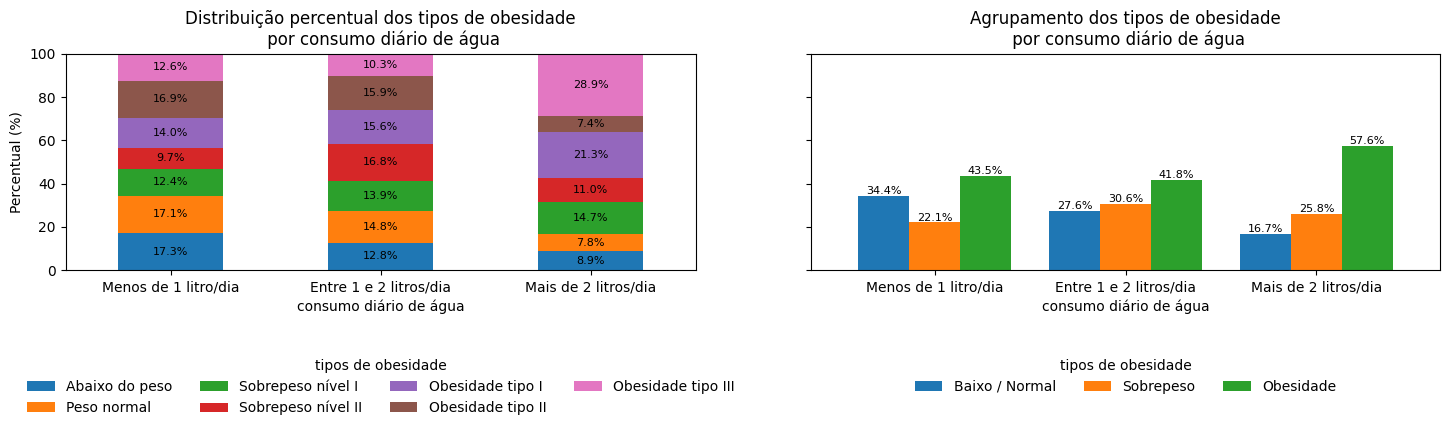

In [21]:
ap.grafico_consumo_de_agua()

O gráfico mostra que não há um padrão consistente entre o consumo diário de água e o controle do peso corporal. Os diferentes níveis de ingestão apresentam distribuições semelhantes entre os graus de obesidade, com presença relevante de sobrepeso e obesidade em todos os grupos. Embora alguns níveis de consumo concentrem maior proporção em categorias específicas, os resultados sugerem que a ingestão de água, de forma isolada, não explica diferenças claras no perfil de peso, indicando a influência de outros fatores comportamentais e de estilo de vida.


### A frequência de consumo de bebidas alcoólicas está associada a diferentes perfis de obesidade?

<p style="color:red;">A frequência de consumo de bebidas alcoólicas deve ser interpretada com cautela, devido à baixa representatividade de consumidores frequentes e sempre na amostra. Apenas ~4% da amostra.</p>


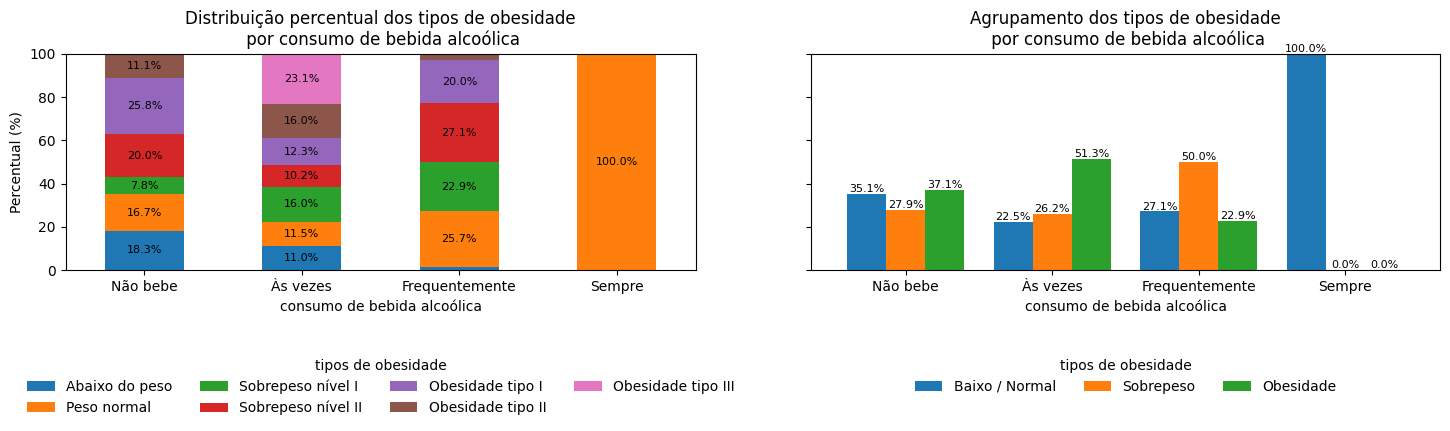

In [22]:
ap.grafico_consumo_bebida_alcoolica()

O gráfico mostra diferenças na distribuição dos níveis de obesidade entre as frequências de consumo de bebidas alcoólicas; no entanto, os resultados devem ser interpretados com cautela devido à forte desproporção entre os grupos, especialmente o grupo que consome bebidas alcoólicas sempre, representado por apenas um indivíduo. Observa-se que os grupos “frequentemente” e “às vezes” apresentam maior dispersão entre os níveis de sobrepeso e obesidade, enquanto o grupo “não bebe” concentra-se principalmente nos níveis intermediários. Dada a baixa representatividade de alguns grupos, os dados não permitem afirmar uma influência clara do consumo de álcool sobre o controle do peso corporal, sugerindo que outros fatores comportamentais podem estar envolvidos.

### Existem diferenças no perfil de obesidade entre fumantes e não fumantes?

<p style="color:red;">A análise do hábito de fumar deve ser interpretada com cautela, devido à baixa representatividade de fumantes na amostra. Apenas ~2% da amostra são fumantes.</p>


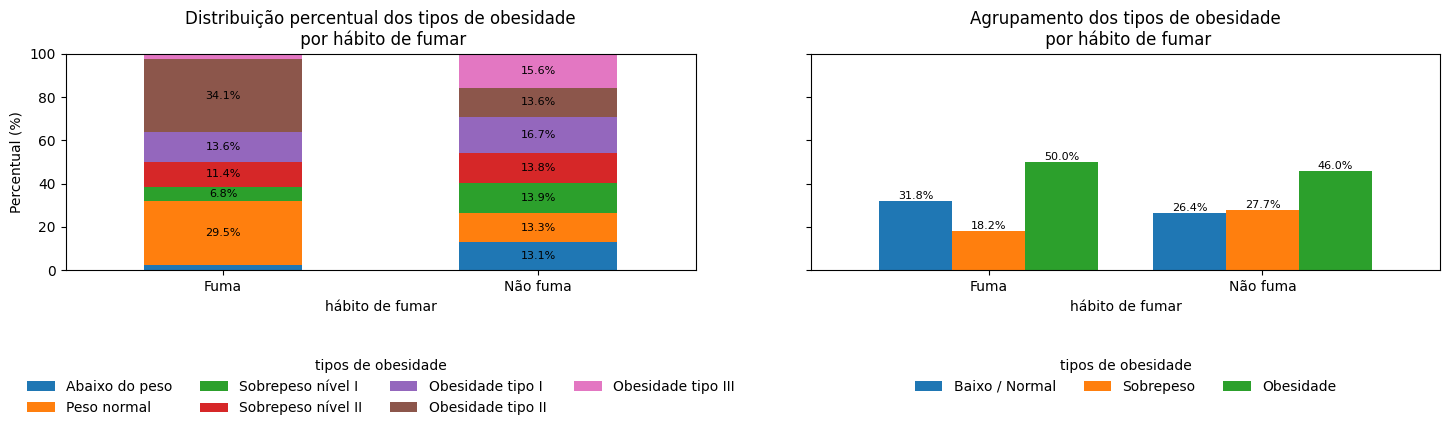

In [23]:
ap.grafico_habito_de_fumar()

O gráfico apresenta diferenças na distribuição dos níveis de obesidade entre fumantes e não fumantes; no entanto, esses resultados devem ser interpretados com cautela devido à baixa representatividade do grupo de fumantes na amostra. Observa-se que, entre os fumantes, há maior concentração em obesidade tipo II, enquanto o grupo de não fumantes apresenta uma distribuição mais homogênea entre os diferentes níveis de obesidade. Dada a reduzida dimensão do grupo de fumantes, os percentuais observados podem ser fortemente influenciados por poucos indivíduos, não permitindo a identificação de um padrão consistente sobre a relação entre o hábito de fumar e o controle do peso corporal.

### Existe associação entre o monitoramento da ingestão calórica diária e os níveis de obesidade?

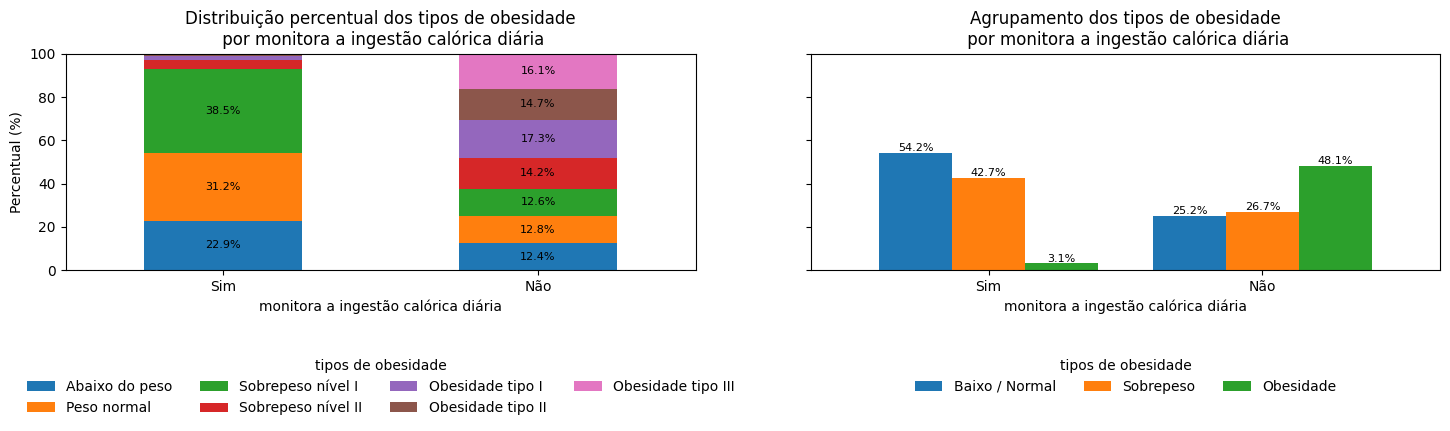

In [24]:
ap.grafico_monitoramento_ingestao_calorica()

Indivíduos que monitoram a ingestão calórica concentram-se nas categorias de peso mais favoráveis, com baixa presença nos níveis mais elevados de obesidade. Já entre os que não monitoram, a distribuição é mais homogênea, com maior participação nas faixas de sobrepeso e obesidade.
Esse padrão indica uma associação entre o monitoramento calórico e o controle do peso, embora não permita inferir causalidade devido à desproporção da amostra. Apenas 4,5% (96 pessoas) monitoram a ingestão de calorias diariamente.

### Conclusão dos comportamentos adicionais

A análise dos comportamentos adicionais mostra que nem todos os hábitos apresentam associação clara com o controle do peso corporal quando avaliados isoladamente.

A ingestão de água, por exemplo, não demonstra um padrão consistente entre os diferentes níveis de obesidade, sugerindo que, embora importante para a saúde geral, seu impacto direto sobre o peso pode depender da interação com outros fatores.

O consumo de bebidas alcoólicas também não apresenta relação conclusiva, especialmente devido à desproporção entre os grupos analisados. Da mesma forma, o hábito de fumar não revela um padrão consistente, sendo fortemente influenciado pela baixa representatividade da amostra de fumantes.

Por outro lado, o monitoramento da ingestão calórica se destaca como o comportamento mais associado a perfis de peso mais favoráveis. Indivíduos que acompanham suas calorias concentram-se majoritariamente nas categorias mais equilibradas, enquanto aqueles que não monitoram apresentam maior presença em sobrepeso e obesidade. Ainda assim, a baixa proporção de indivíduos que realizam esse acompanhamento exige cautela na interpretação.

Em conjunto, os dados reforçam uma conclusão importante: não são hábitos isolados que determinam o perfil de obesidade, mas sim a combinação estruturada de comportamentos ao longo do tempo.

Se nos capítulos anteriores identificamos fatores demográficos, alimentares e de estilo de vida como elementos centrais, agora compreendemos que a consciência e o controle intencional sobre os próprios hábitos podem representar um diferencial relevante.

# Conclusão Geral

A análise demonstra que a obesidade é um fenômeno multifatorial, resultante da interação entre características individuais, padrões alimentares e estilo de vida.

Fatores demográficos como sexo, idade e histórico familiar delineiam o perfil inicial de risco, com destaque para a transição entre os 20 e 39 anos como período crítico de progressão do excesso de peso. No campo alimentar, o consumo frequente de alimentos altamente calóricos mostrou associação consistente com níveis mais severos de obesidade, enquanto outros hábitos, como consumo de vegetais e número de refeições, revelaram que o padrão alimentar deve ser analisado de forma integrada.

No estilo de vida, a prática regular de atividade física apresentou relação com perfis de peso mais equilibrados, enquanto comportamentos sedentários indicaram possível influência na severidade da obesidade. Já comportamentos adicionais, como ingestão de água, consumo de álcool e tabagismo, não demonstraram padrões conclusivos quando analisados isoladamente. O monitoramento da ingestão calórica destacou-se como comportamento associado a perfis mais favoráveis, embora represente pequena parcela da amostra.

É importante ressaltar que algumas categorias apresentaram baixa representatividade, o que limita inferências mais robustas e exige cautela na interpretação dos resultados.

De forma geral, os achados reforçam que não existe um único fator determinante, mas sim um conjunto de comportamentos e predisposições que, combinados ao longo do tempo, influenciam o desenvolvimento e a progressão da obesidade.